# Test Deep Learning Algorithms

**Table of contents**<a id='toc0_'></a>    
- 1. [Settings](#toc1_)    
- 2. [DP](#toc2_)    
- 3. [DL](#toc3_)    
- 4. [Reward](#toc4_)    
- 5. [Compare saving rates](#toc5_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch

In [3]:
import matplotlib.pyplot as plt
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})

In [4]:
from EconDLSolvers import choose_gpu

In [5]:
from BufferStockModel import BufferStockModelClass
from BufferStockModelEGM import BufferStockModelEGMClass

## 1. <a id='toc1_'></a>[Settings](#toc0_)

In [6]:
par = {'Nstates_fixed':0,'bequest':0.5,'full':False}
K_time = 0.1

## 2. <a id='toc2_'></a>[DP](#toc0_)

In [7]:
model_dp = BufferStockModelEGMClass(name='DP',par=par)

In [8]:
model_dp.solve_EGM()
model_dp.simulate_R()
print(f'R = {model_dp.sim.R:12.8f}')

R =  -1.11847252


## 3. <a id='toc3_'></a>[DL](#toc0_)

In [9]:
device = choose_gpu()

GPU 0: 44.40GB free [NVIDIA L40]
Best GPU: 0


In [10]:
algonames = ['DeepSimulate','DeepFOC','DeepVPD','DeepVPD-FOC']

In [11]:
models_dl = {}

In [12]:
for algoname in algonames:
    for terminal_actions_known in [True,False]:

        print(f'### {algoname} [{terminal_actions_known}] ###')

        algoname_ = algoname if not algoname in ['DeepVPD-FOC'] else 'DeepVPD'
        if 'DeepVPD' in algoname:
            use_FOC = True if algoname == 'DeepVPD-FOC' else False
        else:
            use_FOC = None

        train={
            'K_time':K_time,
            'terminal_actions_known':terminal_actions_known,
            'use_FOC':use_FOC,
        }

        model_dl = BufferStockModelClass(algoname=algoname_,device=device,par=par,train=train)
        model_dl.solve(do_print=True)
        models_dl[(algoname,terminal_actions_known)] = model_dl
        
        print('')

### DeepSimulate [True] ###


started solving: 2026-01-30 22:39:58


k =     0 of inf: sim.R =    -1.27111077 [best:    -1.27111077] [0.5 secs] [value_epochs =   0] [policy_epochs =   1] [  0.01 mins] [policy_lr = 1.0e-03]


k =    50 of inf: sim.R =    -1.12992144 [best:    -1.12992144] [0.2 secs] [value_epochs =   0] [policy_epochs =   1] [  0.04 mins] [policy_lr = 1.0e-03]


k =   100 of inf: sim.R =    -1.12380254 [best:    -1.12380254] [0.2 secs] [value_epochs =   0] [policy_epochs =   1] [  0.08 mins] [policy_lr = 1.0e-03]


...


### DeepVPD-FOC [False] ###
started solving: 2026-01-30 22:40:41
k =     0 of inf: sim.R =    -1.37857318 [best:    -1.37857318] [0.1 secs] [value_epochs =  32] [policy_epochs =   0] [  0.00 mins] [policy_lr = 1.0e-03] [value_lr = 1.0e-03]


k =    10 of inf: sim.R =    -1.21986210 [best:    -1.21986210] [0.2 secs] [value_epochs =  50] [policy_epochs =  15] [  0.02 mins] [policy_lr = 1.0e-03] [value_lr = 1.0e-03]


k =    20 of inf: sim.R =    -1.13123250 [best:    -1.13123250] [0.2 secs] [value_epochs =  50] [policy_epochs =  15] [  0.05 mins] [policy_lr = 1.0e-03] [value_lr = 1.0e-03]


k =    30 of inf: sim.R =    -1.12124932 [best:    -1.12124932] [0.2 secs] [value_epochs =  50] [policy_epochs =  15] [  0.07 mins] [policy_lr = 1.0e-03] [value_lr = 1.0e-03]


k =    40 of inf: sim.R =    -1.11972475 [best:    -1.11972475] [0.2 secs] [value_epochs =  50] [policy_epochs =  15] [  0.10 mins] [policy_lr = 1.0e-03] [value_lr = 1.0e-03]
Terminating after 41 episodes, max time 0.1 mins reached
R = -1.1197, time = 0.1 mins, iter = 41, policy epochs = 11.34, value epochs = 48.61
Simulating multiple Rs



## 4. <a id='toc4_'></a>[Reward](#toc0_)

In [13]:
print(f'DP                     : {model_dp.sim.R : 8.4f}')
for terminal_actions_known in [True,False]:
    for algoname in algonames:
        k = (algoname,terminal_actions_known)
        if not k in models_dl: continue
        model_dl = models_dl[k]
        print(f'{algoname:15s} [{str(terminal_actions_known):5s}]: {model_dl.sim.R : 8.4f}')

DP                     :  -1.1185
DeepSimulate    [True ]:  -1.1227
DeepFOC         [True ]:  -1.1187
DeepVPD         [True ]:  -1.1190
DeepVPD-FOC     [True ]:  -1.1193
DeepSimulate    [False]:  -1.1243
DeepFOC         [False]:  -1.1189
DeepVPD         [False]:  -1.1189
DeepVPD-FOC     [False]:  -1.1197


In [14]:
TrueSavingsRate = 1-1/(1+model_dp.par.beta*model_dp.par.bequest)
print(f'TrueSavingsRate: {TrueSavingsRate:.4f}')
print(f'DP: {model_dp.sim.actions[-1,:,0].mean():.4f}')
for terminal_actions_known in [True,False]:
    for algoname in algonames:
        k = (algoname,terminal_actions_known)
        if not k in models_dl: continue
        model_dl = models_dl[k]
        print(f'{algoname:15s} [{str(terminal_actions_known):5s}]: {model_dl.sim.actions[-1,:,0].mean() :.4f}')

TrueSavingsRate: 0.3311
DP: 0.3311
DeepSimulate    [True ]: 0.3311
DeepFOC         [True ]: 0.3311
DeepVPD         [True ]: 0.3311
DeepVPD-FOC     [True ]: 0.3311
DeepSimulate    [False]: 0.3318
DeepFOC         [False]: 0.3309
DeepVPD         [False]: 0.3319
DeepVPD-FOC     [False]: 0.3311


## 5. <a id='toc5_'></a>[Compare saving rates](#toc0_)

In [15]:
lss = ['--','-.',':',(0,(3,5,1,5))]

### terminal_actions_known = True ###


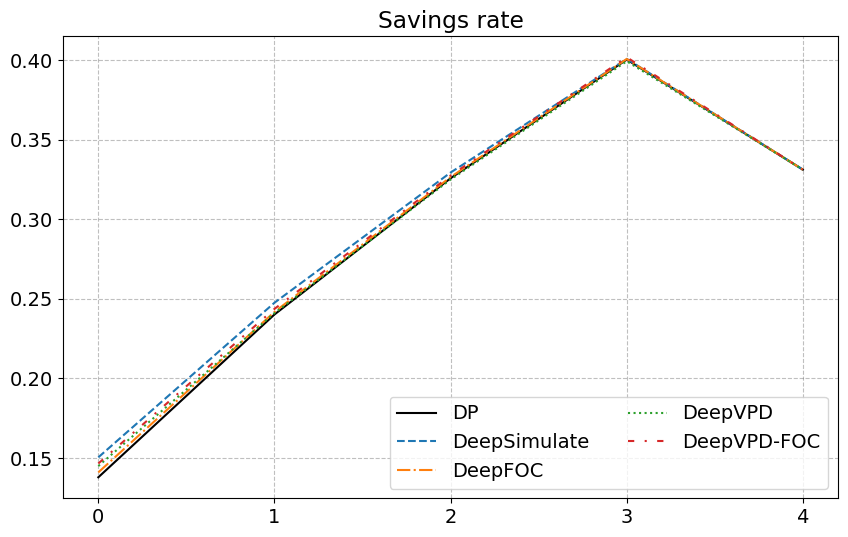

### terminal_actions_known = False ###


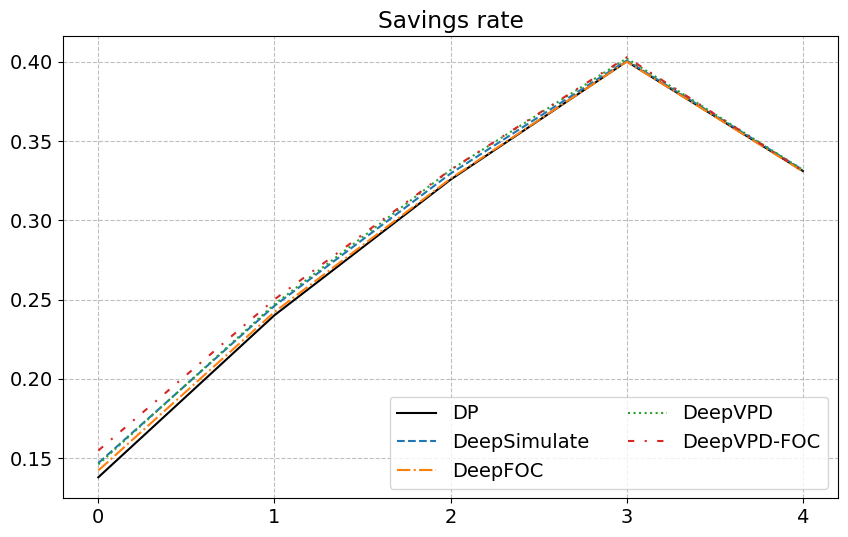

In [16]:
for terminal_actions_known in [True,False]:

    print(f'### {terminal_actions_known = } ###')
    fig,ax = plt.subplots(1,1,figsize=(10,6))
    ax.plot(model_dp.sim.actions[:,:,0].mean(axis=1),label='DP',color='black')
    
    for i,algoname in enumerate(algonames):

        k = (algoname,terminal_actions_known)
        if not k in models_dl: continue
        model_dl = models_dl[k]

        ax.plot(model_dl.sim.actions[:,:,0].cpu().mean(axis=1),label=f'{algoname}',color=colors[i],ls=lss[i])

    ax.set_title(f'Savings rate')
    ax.legend(ncol=2,loc='lower right')
    ax.set_xticks(np.arange(model_dp.par.T))

    plt.show()